# Introvert-Extrovert Classifier

## Data Exploration

In [113]:
import pandas as pd

### Data Loading

In [114]:
df = pd.read_csv("../data/personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


### Dataset dimensions and statistics 

In [115]:
df.shape

(2900, 8)

In [116]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 221.4 KB


In [117]:
df.describe(include="all")

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
count,2837.000000,2827,2838.000000,2834.000000,2848,2823.000000,2835.000000,2900
unique,NaN,2,NaN,NaN,2,NaN,NaN,2
top,NaN,No,NaN,NaN,No,NaN,NaN,Extrovert
freq,NaN,1417,NaN,NaN,1441,NaN,NaN,1491
mean,4.505816,NaN,3.963354,3.000000,NaN,6.268863,3.564727,NaN
std,3.479192,NaN,2.903827,2.247327,NaN,4.289693,2.926582,NaN
min,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,2.000000,NaN,2.000000,1.000000,NaN,3.000000,1.000000,NaN
50%,4.000000,NaN,3.000000,3.000000,NaN,5.000000,3.000000,NaN
75%,8.000000,NaN,6.000000,5.000000,NaN,10.000000,6.000000,NaN


### Missingness Exploration

In [118]:
(df.isna().sum()/df.shape[0]) * 100

Time_spent_Alone             2.172414
Stage_fear                   2.517241
Social_event_attendance      2.137931
Going_outside                2.275862
Drained_after_socializing    1.793103
Friends_circle_size          2.655172
Post_frequency               2.241379
Personality                  0.000000
dtype: float64

In [119]:
df_dropped = df.dropna()

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after dropping missing values: {df_dropped.shape}")

print(f"Percentage of data retained: {round((df_dropped.shape[0] / df.shape[0]) * 100, 2)}%")

Original dataset shape: (2900, 8)
Dataset shape after dropping missing values: (2477, 8)
Percentage of data retained: 85.41%


If the complete case analysis is done, 15% of the data will be deleted.
So moving for other imputation methods

In [120]:
int_cols = ["Time_spent_Alone", "Social_event_attendance", "Going_outside", "Post_frequency", "Friends_circle_size"]

cat_cols = ["Stage_fear", "Drained_after_socializing"]

#### Filling `Time_spent_Alone` and `Social_event_attendance` features

Performing a correlation test to fill up the `Time_spent_Alone` column to reduce the information loss when imputing with the mean (for more accurate imputation).

In [126]:
correlation = df[['Social_event_attendance', 'Time_spent_Alone']].corr()
print(correlation)

                         Social_event_attendance  Time_spent_Alone
Social_event_attendance                 1.000000         -0.733011
Time_spent_Alone                       -0.733011          1.000000


1. `Time_spent_Alone`

A strong negative correlation of  -0.733011 means there's a considerable relationship between the two variables. 
As the filling solution, a treshold of 4 will be considered for data bucketing, different mean for different buckets. 

In [127]:
less_event_attenders = df[df['Social_event_attendance'] < 4][['Time_spent_Alone']].mean().iloc[0]
more_event_attenders = df[df['Social_event_attendance'] >= 4][['Time_spent_Alone']].mean().iloc[0]
time_spent_mean = df[['Time_spent_Alone']].mean().iloc[0]

print(less_event_attenders)
print(more_event_attenders)
print(time_spent_mean)



7.438709677419355
1.5336712527154237
4.505816002819881


In [128]:
# values for missing "Social_event_attendance"
df[df["Time_spent_Alone"].isna()]['Social_event_attendance'].isna().sum()

1

In [129]:
# 1. Fill NaN for those who attend fewer than 4 events
df.loc[(df['Time_spent_Alone'].isna()) & (df['Social_event_attendance'] < 4), 'Time_spent_Alone'] = less_event_attenders

# 2. Fill NaN for those who attend 4 or more events
df.loc[(df['Time_spent_Alone'].isna()) & (df['Social_event_attendance'] >= 4), 'Time_spent_Alone'] = more_event_attenders

# 3. Optional: Use the global mean as a fallback for any remaining NaNs
df['Time_spent_Alone'] = df['Time_spent_Alone'].fillna(time_spent_mean)

In [130]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

2. `Social_event_attendance`

In [133]:
# Calculate mean attendance for those who spend a lot of time alone (e.g., >= 4 hours)
more_time_alone = df[df['Time_spent_Alone'] >= 4]['Social_event_attendance'].mean()

# Calculate mean attendance for those who spend little time alone (e.g., < 4 hours)
less_time_alone = df[df['Time_spent_Alone'] < 4]['Social_event_attendance'].mean()

# Overall mean attendance
social_attendance_mean = df['Social_event_attendance'].mean()

print(more_time_alone)
print(less_time_alone)
print(social_attendance_mean)


1.5318404478656402
6.429382540809084
3.963354474982382


In [134]:
# values for missing "Time_spent_Alone"
df[df["Social_event_attendance"].isna()]['Time_spent_Alone'].isna().sum()

0

In [135]:
# 1. Fill NaN for those who spend LESS than 4 hours alone
df.loc[(df['Social_event_attendance'].isna()) & (df['Time_spent_Alone'] < 4), 'Social_event_attendance'] = less_time_alone

# 2. Fill NaN for those who spend 4 or MORE hours alone
df.loc[(df['Social_event_attendance'].isna()) & (df['Time_spent_Alone'] >= 4), 'Social_event_attendance'] = more_time_alone

# 3. Optional: Use the global mean as a fallback
df['Social_event_attendance'] = df['Social_event_attendance'].fillna(social_attendance_mean)


In [136]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

#### Filling `Going_outsisde`


In [138]:
correlation = df[['Social_event_attendance', 'Going_outside']].corr()
print(correlation)

                         Social_event_attendance  Going_outside
Social_event_attendance                 1.000000       0.749767
Going_outside                           0.749767       1.000000


Here, A Strong positive correlation of 0.749767 means, if the persons social event attendance is high, the count of going outside should be likely high. So, when filling missing values, rather than filling it with a general mean, it is a better approach to fill it with a suitable mean of a subset of values.  

In [141]:
# Mean outside time for those with low vs high event attendance
less_event_outside = df[df['Social_event_attendance'] < 5]['Going_outside'].mean()
more_event_outside = df[df['Social_event_attendance'] >= 5]['Going_outside'].mean()
total_outside_mean = df['Going_outside'].mean()

print(less_event_outside)
print(more_event_outside)
print(total_outside_mean)

1.661896243291592
4.939498703543648
3.0


In [142]:
# Fill NaN based on social event attendance categories
df.loc[(df['Going_outside'].isna()) & (df['Social_event_attendance'] < 5), 'Going_outside'] = less_event_outside
df.loc[(df['Going_outside'].isna()) & (df['Social_event_attendance'] >= 5), 'Going_outside'] = more_event_outside

# Global fallback
df['Going_outside'] = df['Going_outside'].fillna(total_outside_mean)


In [143]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                 0
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

#### Filling `Friends_circle_size`

In [147]:
correlation = df[['Friends_circle_size', 'Social_event_attendance']].corr()
print(correlation)

                         Friends_circle_size  Social_event_attendance
Friends_circle_size                 1.000000                 0.736006
Social_event_attendance             0.736006                 1.000000


Since the correlation between Friends_circle_size and Social_event_attendance is quite high (0.736). There's a relation

In [149]:
# Mean circle size for those with low vs high event attendance
less_event_friends = df[df['Social_event_attendance'] < 4]['Friends_circle_size'].mean()
more_event_friends = df[df['Social_event_attendance'] >= 4]['Friends_circle_size'].mean()
total_friends_mean = df['Friends_circle_size'].mean()

print(f"Mean friends circle size for those with low event attendance: {less_event_friends}")
print(f"Mean friends circle size for those with high event attendance: {more_event_friends}")
print(f"Global mean friends circle size: {total_friends_mean}")


Mean friends circle size for those with low event attendance: 2.7114707952146375
Mean friends circle size for those with high event attendance: 9.874465049928673
Global mean friends circle size: 6.268862911795962


In [150]:
# 1. Fill NaN for those who attend fewer than 4 events
df.loc[(df['Friends_circle_size'].isna()) & (df['Social_event_attendance'] < 4), 'Friends_circle_size'] = less_event_friends

# 2. Fill NaN for those who attend 4 or more events
df.loc[(df['Friends_circle_size'].isna()) & (df['Social_event_attendance'] >= 4), 'Friends_circle_size'] = more_event_friends

# 3. Use the global mean as a fallback
df['Friends_circle_size'] = df['Friends_circle_size'].fillna(total_friends_mean)


In [151]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                 0
Drained_after_socializing    52
Friends_circle_size           0
Post_frequency               65
Personality                   0
dtype: int64

#### Filling `Post_frequency`

In [152]:
correlation = df[['Friends_circle_size', 'Post_frequency']].corr()
print(correlation)

                     Friends_circle_size  Post_frequency
Friends_circle_size               1.0000          0.7107
Post_frequency                    0.7107          1.0000


In [156]:
# Mean posting frequency for small vs large friend circles
less_friends_posts = df[df['Friends_circle_size'] < 5]['Post_frequency'].mean()
more_friends_posts = df[df['Friends_circle_size'] >= 5]['Post_frequency'].mean()
total_posts_mean = df['Post_frequency'].mean()

print(f"Mean posting frequency for small friend circles: {less_friends_posts}")
print(f"Mean posting frequency for large friend circles: {more_friends_posts}")
print(f"Global mean posting frequency: {total_posts_mean}")


Mean posting frequency for small friend circles: 1.1494632535094962
Mean posting frequency for large friend circles: 5.365763546798029
Global mean posting frequency: 3.564726631393298


In [157]:
# 1. Fill NaN for those with a friend circle size smaller than 4
df.loc[(df['Post_frequency'].isna()) & (df['Friends_circle_size'] < 4), 'Post_frequency'] = less_friends_posts

# 2. Fill NaN for those with a friend circle size of 4 or more
df.loc[(df['Post_frequency'].isna()) & (df['Friends_circle_size'] >= 4), 'Post_frequency'] = more_friends_posts

# 3. Use the global mean as a fallback
df['Post_frequency'] = df['Post_frequency'].fillna(total_posts_mean)


In [158]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                 0
Drained_after_socializing    52
Friends_circle_size           0
Post_frequency                0
Personality                   0
dtype: int64

#### Filling `Drained_after_socializing`

In [162]:
df['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     1441
Yes    1407
Name: count, dtype: int64

In [ ]:
df[df['Going_outside'] > 2]['Drained_after_socializing'].value_counts()

Drained_after_socializing
No     1436
Yes      25
Name: count, dtype: int64

There's a more chance that the `Drained_after_socializing` becomes "No" when `Going_outside` is greater than 2. So using that to impute missing values of `Drained_after_socializing`

In [184]:
# 1. Fill NaN with 'No' for those who go outside more than 2 times
df.loc[(df['Drained_after_socializing'].isna()) & (df['Going_outside'] > 2), 'Drained_after_socializing'] = 'No'

# 2. Fill NaN with 'Yes' for those who go outside 2 or fewer times 
# (Since the overall count is almost 50/50, but 'No' is concentrated in the >2 group)
df.loc[(df['Drained_after_socializing'].isna()) & (df['Going_outside'] <= 2), 'Drained_after_socializing'] = 'Yes'

# 3. Fallback: Fill any remaining with the global mode
global_mode_drained = df['Drained_after_socializing'].mode()[0]
df['Drained_after_socializing'] = df['Drained_after_socializing'].fillna(global_mode_drained)


In [185]:
df.isna().sum()

Time_spent_Alone              0
Stage_fear                   73
Social_event_attendance       0
Going_outside                 0
Drained_after_socializing     0
Friends_circle_size           0
Post_frequency                0
Personality                   0
dtype: int64

#### Filling `Stage_fear`

In [190]:
df[df['Going_outside'] > 3]['Stage_fear'].value_counts()

Stage_fear
No    1238
Name: count, dtype: int64

People who go outside more often, they are less likely to have stage fear

In [191]:
# 1. Fill NaN with 'No' for those who go outside more than 3 times
df.loc[(df['Stage_fear'].isna()) & (df['Going_outside'] > 3), 'Stage_fear'] = 'No'

# 2. Fill NaN with 'Yes' for those who go outside 3 or fewer times
# (This assumes the 'Yes' cases are concentrated in the lower 'Going_outside' group)
df.loc[(df['Stage_fear'].isna()) & (df['Going_outside'] <= 3), 'Stage_fear'] = 'Yes'

# 3. Fallback: Fill any remaining with the global mode (most common value)
df['Stage_fear'] = df['Stage_fear'].fillna(df['Stage_fear'].mode()[0])


In [192]:
df.isna().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

### Distribution of the target variable

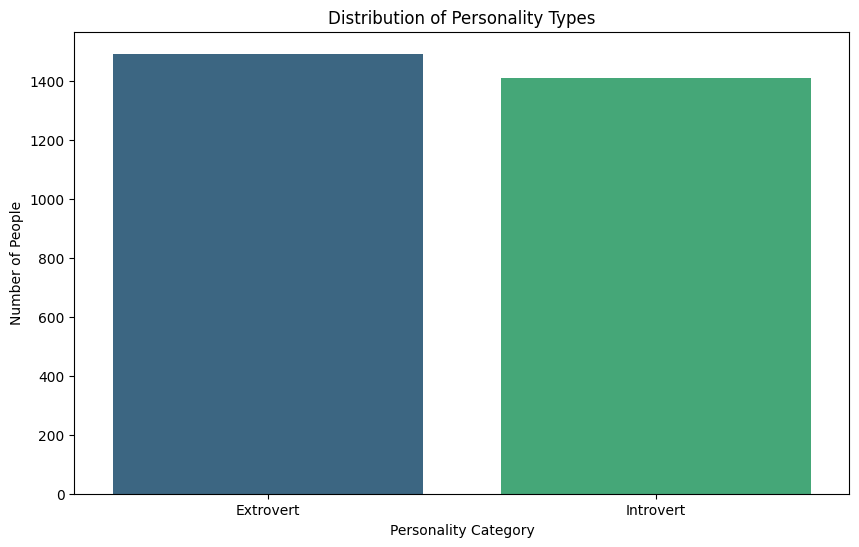

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))


sns.countplot(data=df, x='Personality', hue='Personality', palette='viridis', legend=False)

plt.title('Distribution of Personality Types')
plt.xlabel('Personality Category')
plt.ylabel('Number of People')

# Display the plot
plt.show()


Note: There's no any considerable imbalance in the target variable

### Distribution of independent variables for outlier detection

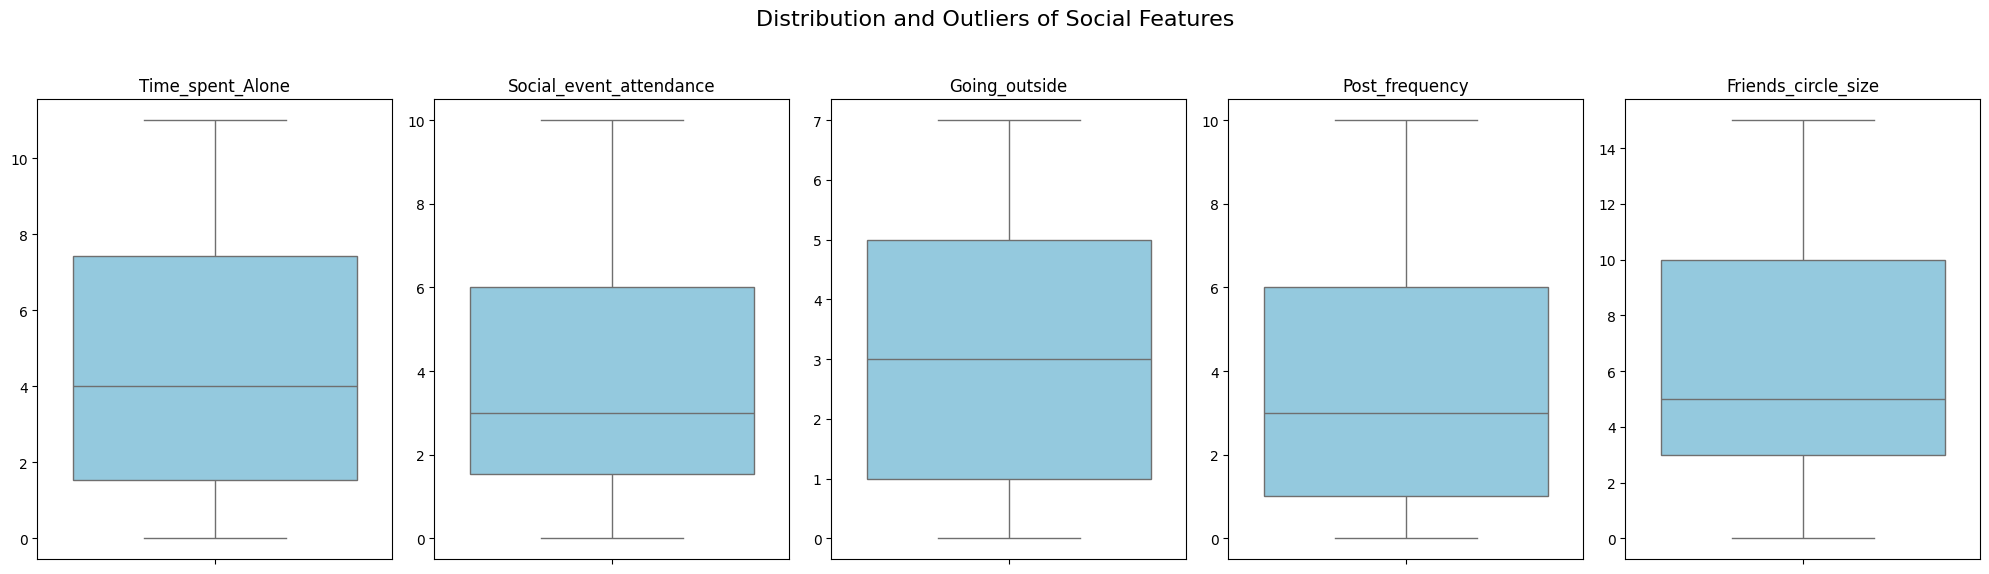

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Post_frequency', 'Friends_circle_size']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Distribution and Outliers of Social Features', fontsize=16)

for i, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('')  

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Note: No considerable outliers found

## Data Pre-processing Pipeline

### Defining the pipeline

In [196]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

class BinaryMapper(BaseEstimator, TransformerMixin):
    def __init__(self, yes_val=1, no_val=0):
        self.yes_val = yes_val
        self.no_val = no_val
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_temp = X.copy()
        # Maps Yes to 1 and No to 0
        return X_temp.replace({'Yes': self.yes_val, 'No': self.no_val})
    
binary_cols = ['Drained_after_socializing', 'Stage_fear']
numeric_cols = ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Post_frequency', 'Friends_circle_size']

preprocessor = ColumnTransformer(
    transformers=[
        ('bin', BinaryMapper(), binary_cols),
        ('num', StandardScaler(), numeric_cols)
    ],
    remainder='passthrough' # Keeps other columns like 'Personality' as they are
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])


